<a href="https://colab.research.google.com/github/Bubukisapisa/ML_midterm_project/blob/main/Mid_term_Project_preproc_model_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Вітаю вас на Mid-term проєкті!

Цей проєкт призначений для того, щоб ви могли оновити та закріпити знання, які ви отримали за перші місяці навчання на курсі "Machine Learning для людей".

### Основна задача

В цьому завданні Ви - Data Scientist в барнку. Ваша задача - побудувати модель для передбачення, чи оформить клієнт в банку строковий депозит (term deposit). З подібними задачами ми стикаємось в різних компаніях і доменах, коли хочемо зрозуміти, чи клієнт купить якийсь продукт, чи буде користуватись нашим сервісом/сайтом у наступному місяці, чи придбає підписку.

Вам треба не просто побудувати модель, а і пояснити замовнику (ваш замовник тут - це ми з кураторами) як працює ця модель і чому вона дає саме такі рішення. Без цього розуміння ми не можемо перейти до впроваждення (деплойменту) моделі в продакшен.

### Практичне застовування

В реальних робочих умовах в подібних задачах у Вас дані будуть зберігатись в базі данних в динаміці (різні дії користувачів з датою і часом). Тут дані вже загреговані по клієнтам і часто саме з цього ви будете починати побудову моделі передбачення, адже це відносно просто і зручно: загрегувати дані по клієнтам до певного часу і передбачати в майбутнє (тільки в випадку тренування моделі ML наше "майбутнє" теж фактично в минулому - бо ми хочемо мати мітки в даних, а от вже при використанні моделі в продакшені і бойових умовах ви справді будете робити передбачення в майбутнє). Тож, розвʼязуємо задачку!

### Датасет і ML задача

Для виконання завдання ми використаємо набір даних, який оригінально походить з сайту [UCI Machine Learning Repository], але там неточний опис даних і багато різних піднаборів, тому ми братимемо з Kaggle dataset: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv.

Ці дані стосуються прямих маркетингових кампаній (телефонних дзвінків) португальської банківської установи. Кінцева мета класифікації - передбачити, чи підпише клієнт строковий депозит (змінна y).

Ми будемо працювати з файлом `bank-additional-full.csv`, скачати набір даних треба з Kaggle. Або можна скачати цей самий набір з гугл диска [тут](https://drive.google.com/file/d/1pDr0hAOnu1JsEiJeBu_F2Jv0GPxKiujW/view?usp=drive_link)

### Опис змінних

Цей опис є і на Kaggle, але ми переклали для вашої зручності і аби він був у вас перед очима під час роботи над проєктом.

#### **Дані про клієнта банку**:
1. **age** – вік клієнта (числова змінна).  
2. **job** – вид зайнятості (категоріальна змінна: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – сімейний стан (категоріальна змінна: `divorced`, `married`, `single`, `unknown`; примітка: `divorced` означає розлучений або вдівець/вдова).  
4. **education** – рівень освіти (категоріальна змінна: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – чи є у клієнта прострочений кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
6. **housing** – чи має клієнт іпотечний кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
7. **loan** – чи має клієнт споживчий кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  

#### **Дані про останній контакт у межах поточної маркетингової кампанії**:
8. **contact** – тип зв’язку при останньому контакті (категоріальна змінна: `cellular`, `telephone`).  
9. **month** – місяць останнього контакту (категоріальна змінна: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – день тижня останнього контакту (категоріальна змінна: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – тривалість останнього контакту в секундах (числова змінна).  
   ⚠ **Важлива примітка**: ця змінна має суттєвий вплив на цільову змінну (наприклад, якщо duration = 0, то y = `no`). Однак значення duration невідоме до здійснення дзвінка. Крім того, після завершення дзвінка значення y вже відоме. Тому цю змінну варто використовувати лише для порівняння моделей, але не включати у фінальну передбачувальну модель.  

#### **Інші атрибути**:
12. **campaign** – кількість контактів у межах поточної кампанії для цього клієнта (числова змінна, включає останній контакт).  
13. **pdays** – кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (числова змінна; значення 999 означає, що клієнт раніше не контактувався).  
14. **previous** – кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).  
15. **poutcome** – результат попередньої маркетингової кампанії (категоріальна змінна: `failure`, `nonexistent`, `success`).  

#### **Атрибути соціально-економічного контексту**:
16. **emp.var.rate** – темп зміни зайнятості (щоквартальний показник, числова змінна).  
17. **cons.price.idx** – індекс споживчих цін (щомісячний показник, числова змінна).  
18. **cons.conf.idx** – індекс довіри споживачів (щомісячний показник, числова змінна).  
19. **euribor3m** – ставка Euribor на 3 місяці (щоденний показник, числова змінна).  
20. **nr.employed** – кількість працевлаштованих осіб (щоквартальний показник, числова змінна).  

#### **Цільова змінна**:
21. **y** – чи підписав клієнт строковий депозит? (бінарна змінна: `yes`, `no`).

### Ваше завдання на цей проєкт

Необхідно побудувати рішення цієї задачі бінарної класифікації. Для цього

1. Провести Exploratory Data Analysis і висунути гіпотези щодо впливу окремих ознак на цільову ознаку `y`.

2. Описати, які методи ви вважаєте доречним використовувати і обрати метрику оцінки якості моделей (метрику треба обґрунтувати).

3. Провести препроцесинг даних для подальшої їх передачі в модель. Препроцесинг має включати
  - обробку категоріальних змінних (якщо цього потребує модель)
  - групування категорій в категоріальних змінних, якщо потрібно
  - заповнення пропущених значень, якщо такі є
  - виявлення outliers і прийняття рішень, що з ними робити
  - створення додаткових ознак, які на ваш погляд поліпшать якість моделей ML.

4. Натренувати 4 різні типи моделей машинного навчання, з яких обовʼязково
  - Logistic Regression
  - kNN
  - Decision Tree
  - Принаймні один з алгоритмів бустингу

5. Створити таблицю з порівнянням якості моделей (в Google Spreadsheets або прямо в Jupyter Notebook), де зазначити
  - назву моделі
  - гіперпараметри
  - метрика якості моделі на тренувальному наборі
  - метрика якості моделі на валідаційному наборі даних
  - коментар до моделі - хороша вона, чи ні, чи варто її використовувати чи ні, чи є у вас подальші ідеї щодо експериментів з цією моделлю?

6. Для алгоритму бустингу виконати процедуру тюнингу гіперпараметрів двома способами
  - Sklearn: Randomized Search
  - Hyperopt: Bayesian Optimization.
  Виявити оптимальні гіперпараметри і зробити висновки про якість моделі в кожному з випадків.

7. Вивести важливість ознак для моделі, які показала себе найкраще і описати, чи вважаєте ви саме такий пріоритет важливості ознак адекватним з точки зору common sense?

8. Для найкращої провести аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.

9. Провести аналіз записів, в яких модель помиляється і на основі нього зазначити, яким чином можна поліпшити наявне рішення аби уникати наявних помилок?


### Результат виконання проєкту

Результатом виконання цього завдання є окремий github репозиторій з охайно оформленим Jupyter Notebook, частина коду може бути винесена в .py файли. Репозиторій має містити опис задачі, опис що було зроблено і які моделі використано, таблицю результатів експериментів (можна скріншотом або створити таблицю в Markdown форматі - див. Приклад) і висновки, що Ви досягли і що можна було б ще зробити для поліпшення результатів.


### Приклад проєкту

Для натхнення ви можете ознайомитись з проєктом, побудованим на основі цих даних за [цим посиланням](https://github.com/surtantheta/Bank_Marketing_Dataset_Machine_Learning_Project).




![](https://blogconcept2competence.wordpress.com/wp-content/uploads/2014/03/yoda.jpg)

In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate
from sklearn import preprocessing
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score,roc_auc_score
import time
import matplotlib.pyplot as plt
import seaborn as sns
from compute_column_stats import compute_column_stats
from categorical_stats_compare import uni_cat_target_compare as uctc
from plot_conversion import plot_conversion
from preprocessing import preproc_bef_split
from preprocessing import split_data
from preprocessing import transform_after_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve, auc

In [2]:
df_prep = preproc_bef_split(pd.read_csv('bank-additional-full.csv', sep=';'))

In [3]:
df_prep.head()

,age,job,marital,education,default,contact,month,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,was_contacted,pdays_real
0,56,housemaid,married,basic.4y,1,0,may,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0
1,57,services,married,high.school,0,0,may,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0
2,37,services,married,high.school,1,0,may,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0
3,40,admin.,married,basic.6y,1,0,may,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0
4,56,services,married,high.school,1,0,may,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0


In [4]:
X_train_sep, X_val_sep, X_test_sep, y_train, y_val, y_test = split_data(df_prep)

Train: 24,711 | Val: 8,238 | Test: 8,238


In [5]:
X_train_sep.columns

Index(['age', 'job', 'marital', 'education', 'default', 'contact', 'month',
       'campaign', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted',
       'pdays_real'],
      dtype='object')

In [6]:
X_test_sep.columns

Index(['age', 'job', 'marital', 'education', 'default', 'contact', 'month',
       'campaign', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted',
       'pdays_real'],
      dtype='object')

In [7]:
X_train, X_val, X_test = transform_after_split(X_train_sep, X_val_sep, X_test_sep, y_train)

Готово!
X_train shape: (24711, 22)
Колонки: ['age', 'job', 'education', 'default', 'contact', 'month', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted', 'pdays_real', 'marital_divorced', 'marital_married', 'marital_single', 'marital_unknown', 'poutcome_failure', 'poutcome_nonexistent', 'poutcome_success']


In [8]:
X_train.default.value_counts()

,count
default,
1,19627
0,5084


##Робота з моделями
####Логістична регресія

In [9]:
lin_reg = LogisticRegression(solver = 'liblinear', class_weight="balanced")

In [10]:
lin_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', solver='liblinear')

In [11]:
train_pred = lin_reg.predict(X_train)

In [12]:
accuracy_score(y_train, train_pred)

0.8112581441463316

In [13]:
val_pred = lin_reg.predict(X_val)

In [14]:
accuracy_score(y_val, val_pred)

0.8143966982277252

In [15]:
print(classification_report(y_train, train_pred, digits=4))
print(classification_report(y_val, val_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9480    0.8330    0.8868     21927
           1     0.3273    0.6401    0.4332      2784

    accuracy                         0.8113     24711
   macro avg     0.6377    0.7365    0.6600     24711
weighted avg     0.8781    0.8113    0.8357     24711

              precision    recall  f1-score   support

           0     0.9493    0.8354    0.8887      7310
           1     0.3335    0.6487    0.4405       928

    accuracy                         0.8144      8238
   macro avg     0.6414    0.7421    0.6646      8238
weighted avg     0.8800    0.8144    0.8383      8238



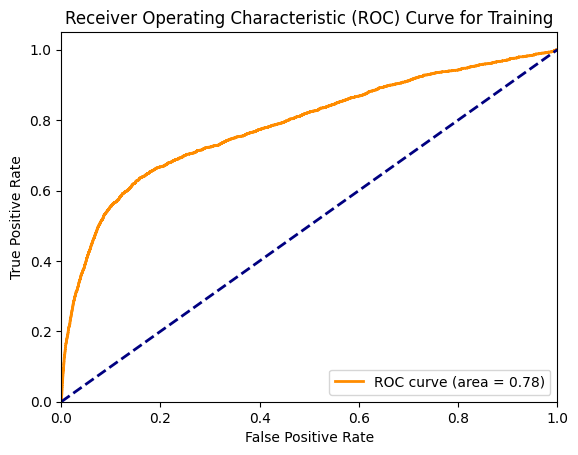

In [16]:
train_pred_proba = lin_reg.predict_proba(X_train)[:, 1]

fpr, tpr, thresholds = roc_curve(y_train, train_pred_proba, pos_label=1.0)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curve for Training')
plt.legend(loc="lower right")
plt.show()

####Висновок по Логістичній регресії

модель добре визначає клас 0, високий precision i recall. Але клас 1 прогнозує значно гірше, recall = 0,64 тобто модель часто дає хибно негативні значення, кожному третьому клієнту, f1 score слабкий.
В модель додав параметр class_weight="balanced" який дає більшої ваги класу 1, інакше модель показує себе ще гірше

####Модель DecisionTree

In [24]:
dec_tree = DecisionTreeClassifier(random_state=42)
dec_tree.fit(X_train, y_train)

train_pred_dt = dec_tree.predict(X_train)
val_pred_dt = dec_tree.predict(X_val)

In [25]:
print(classification_report(y_train, train_pred_dt, digits=4))
print(classification_report(y_val, val_pred_dt, digits=4))

              precision    recall  f1-score   support

           0     0.9973    1.0000    0.9986     21927
           1     0.9996    0.9784    0.9889      2784

    accuracy                         0.9975     24711
   macro avg     0.9985    0.9892    0.9938     24711
weighted avg     0.9975    0.9975    0.9975     24711

              precision    recall  f1-score   support

           0     0.9138    0.9079    0.9109      7310
           1     0.3097    0.3254    0.3174       928

    accuracy                         0.8423      8238
   macro avg     0.6118    0.6167    0.6141      8238
weighted avg     0.8458    0.8423    0.8440      8238



Зараз чітко видно що модель перенавчена - f1 для цільового значення змінної (y=1) 0.98 на тренувальному наборі і 0.31 на валідаційному, потрібно підібрати оптимальні гіперпараметри (глибина дерева, мін. к-ть листів)